In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import seaborn as sns
from pathlib import Path
%matplotlib inline

BASE_DIR = Path().resolve().parent # Works in Jupyter Notebook

DATASET_DIR = BASE_DIR / "DATASET"
BACKEND_DIR = BASE_DIR / "BACKEND"
LOADS_DIR = BASE_DIR / "Sentimental_Analysis_Loads" 
dataset_path = DATASET_DIR / "Restaurant_Reviews.tsv"
tfidf_load_path = LOADS_DIR / "tfidf.pkl"
svm_load_path = LOADS_DIR / "svm.pkl"
svm_pipeline_load_path = LOADS_DIR / "svm_pipeline.pkl"
naive_bayes_load_path = LOADS_DIR / "naive_bayes.pkl"
multinomial_nb_pipeline_load_path = LOADS_DIR / "multinomial_nb_pipeline.pkl"

df = pd.read_table(dataset_path)
df

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1
...,...,...
995,I think food should have flavor and texture an...,0
996,Appetite instantly gone.,0
997,Overall I was not impressed and would not go b...,0
998,"The whole experience was underwhelming, and I ...",0


In [ ]:
df['length'] = df['Review'].apply(len)
df

,Review,Liked,length
0,Wow... Loved this place.,1,24
1,Crust is not good.,0,18
2,Not tasty and the texture was just nasty.,0,41
3,Stopped by during the late May bank holiday of...,1,87
4,The selection on the menu was great and so wer...,1,59
...,...,...,...
995,I think food should have flavor and texture an...,0,66
996,Appetite instantly gone.,0,24
997,Overall I was not impressed and would not go b...,0,50
998,"The whole experience was underwhelming, and I ...",0,91


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  1000 non-null   object
 1   Liked   1000 non-null   int64 
 2   length  1000 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 23.6+ KB


In [ ]:
df['Liked'].value_counts()

Liked
1    500
0    500
Name: count, dtype: int64

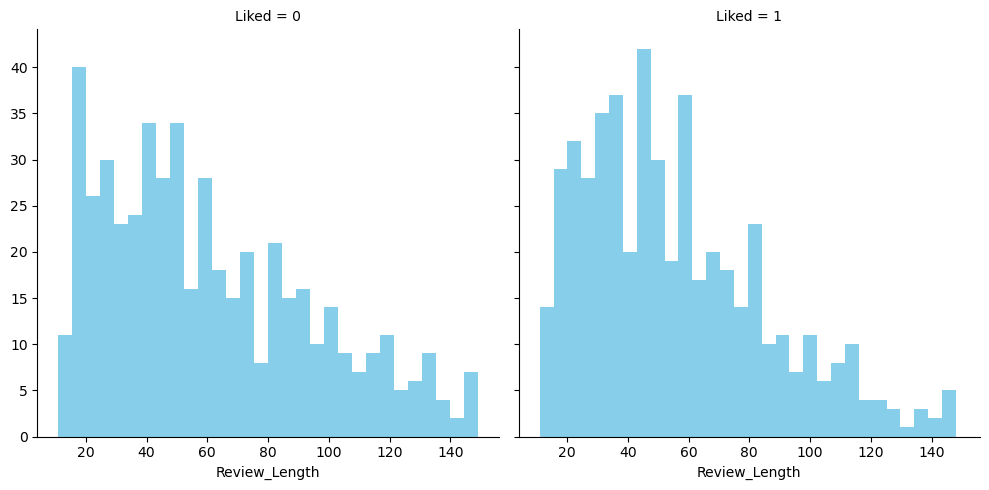

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a new column for review lengths
df["Review_Length"] = df["Review"].apply(len)

# Plot the distribution
g = sns.FacetGrid(df, col="Liked", height=5)
g.map(plt.hist, "Review_Length", bins=30, color="skyblue")

plt.show()


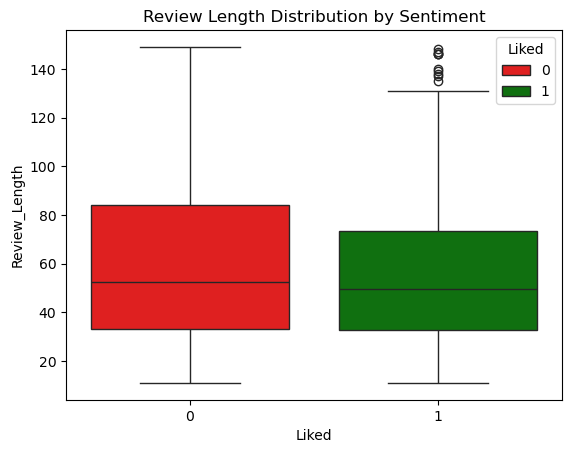

In [ ]:
sns.boxplot(x="Liked", y="Review_Length", data=df, hue="Liked", hue_order=[0, 1], palette=["red", "green"])
plt.title("Review Length Distribution by Sentiment")
plt.show()


In [ ]:
[df['Review'][55],df['Liked'][55]]

['Loved it...friendly servers, great food, wonderful and imaginative menu.', 1]

In [ ]:
import pandas as pd
import re

def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # Remove special characters
    return text

df["Clean_Review"] = df["Review"].apply(clean_text)
x = df["Clean_Review"].values
y = df['Liked'].values
x

array(['wow loved this place', 'crust is not good',
       'not tasty and the texture was just nasty',
       'stopped by during the late may bank holiday off rick steve recommendation and loved it',
       'the selection on the menu was great and so were the prices',
       'now i am getting angry and i want my damn pho',
       'honeslty it didnt taste that fresh',
       'the potatoes were like rubber and you could tell they had been made up ahead of time being kept under a warmer',
       'the fries were great too', 'a great touch',
       'service was very prompt', 'would not go back',
       'the cashier had no care what so ever on what i had to say it still ended up being wayyy overpriced',
       'i tried the cape cod ravoli chicken with cranberrymmmm',
       'i was disgusted because i was pretty sure that was human hair',
       'i was shocked because no signs indicate cash only',
       'highly recommended', 'waitress was a little slow in service',
       'this place is not 

In [ ]:
y

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1,

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0, test_size=0.2)

shapes = [x_train.shape, x_test.shape, y_train.shape, y_test.shape]
print(shapes)



[(800,), (200,), (800,), (200,)]


In [ ]:

import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vect = TfidfVectorizer(stop_words='english', max_features=5000)
# print(x_train[:5]) 
x_train_tfidf = tfidf_vect.fit_transform(x_train)
x_test_tfidf = tfidf_vect.transform(x_test)




In [ ]:
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize and fit a new TF-IDF vectorizer
tfidf_vect = TfidfVectorizer(stop_words='english', max_features=10000)  # Adjust max_features as needed

# Fit the TF-IDF vectorizer on the training data
x_train_tfidf = tfidf_vect.fit_transform(x_train)
x_test_tfidf = tfidf_vect.transform(x_test)

# Define path to save the vectorizer

# tfidf_path = r"D:\GitLab\SENTIMENTAL_ANALYSIS\BACKEND\Sentimental_Analysis_LoadsSentimental_Analysis_tfidf.pkl"
tfidf_path = tfidf_load_path

# Save the TF-IDF vectorizer
with open(tfidf_path, "wb") as f:
    pickle.dump(tfidf_vect, f)

print("✅ TF-IDF vectorizer regenerated & saved successfully!")

# Check transformed shapes
print("Train Data Shape:", x_train_tfidf.shape)
print("Test Data Shape:", x_test_tfidf.shape)

# Verify the features in the newly created TF-IDF
print("Loaded TF-IDF features:", len(tfidf_vect.get_feature_names_out()))


✅ TF-IDF vectorizer regenerated & saved successfully!
Train Data Shape: (800, 1569)
Test Data Shape: (200, 1569)
Loaded TF-IDF features: 1569


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import pickle

# Initialize and train the optimized SVM model
svm_model = SVC(C=1.0, kernel='linear', probability=True)
svm_model.fit(x_train_tfidf, y_train)

# Predict on test data
y_pred_svm = svm_model.predict(x_test_tfidf)

# Evaluate the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Model Accuracy: {accuracy_svm:.4f}")

# Print classification report
print("SVM Classification Report:\n", classification_report(y_test, y_pred_svm))

svm_load = svm_load_path
# Save the trained SVM model
with open(svm_load, "wb") as f:
    pickle.dump(svm_model, f)

print("SVM model saved successfully!")


SVM Model Accuracy: 0.7550
SVM Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.81      0.76        97
           1       0.80      0.70      0.75       103

    accuracy                           0.76       200
   macro avg       0.76      0.76      0.75       200
weighted avg       0.76      0.76      0.75       200

SVM model saved successfully!


In [ ]:

# Load and verify the saved model
with open(svm_load, "rb") as f:
    loaded_svm = pickle.load(f)

print("Test Accuracy after loading:", accuracy_score(y_test, loaded_svm.predict(x_test_tfidf)))


Test Accuracy after loading: 0.755


In [ ]:

# from sklearn.metrics import accuracy_score, classification_report

# y_pred1 = svm_model.predict(x_test_tfidf)  

# accuracy_svm = accuracy_score(y_test, y_pred1)
# print(f"SVM Model Accuracy: {accuracy_svm:.4f}")

# print(classification_report(y_test, y_pred1))
from sklearn.metrics import accuracy_score, classification_report

# Ensure correct format (if needed)
# x_test_tfidf = x_test_tfidf.toarray()  # Uncomment if an error occurs due to sparse matrix

# Predict using the trained SVM model
y_pred_svm = svm_model.predict(x_test_tfidf)

# Calculate accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"\n🔹 SVM Model Accuracy: {accuracy_svm:.4f}\n")

# Print a detailed classification report
print("🔹 Classification Report:\n")
print(classification_report(y_test, y_pred_svm, target_names=['Negative', 'Positive']))




🔹 SVM Model Accuracy: 0.7550

🔹 Classification Report:

              precision    recall  f1-score   support

    Negative       0.72      0.81      0.76        97
    Positive       0.80      0.70      0.75       103

    accuracy                           0.76       200
   macro avg       0.76      0.76      0.75       200
weighted avg       0.76      0.76      0.75       200



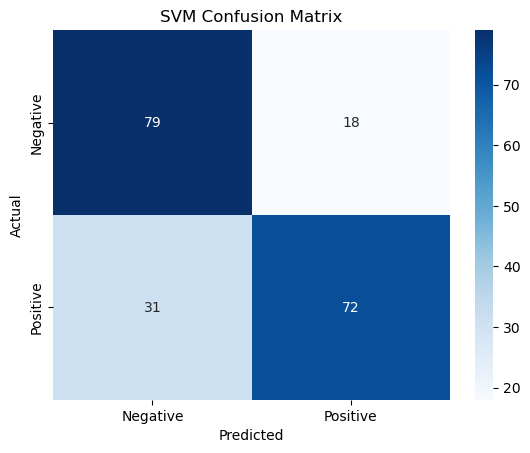

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()


In [ ]:

t = tfidf_vect.transform([df['Review'][993]]) 
prediction = svm_model.predict(t)
print(f"Predicted Sentiment: {prediction[0]}")
print(df['Review'][993]) 
print(df['Liked'][993])    

Predicted Sentiment: 0
the presentation of the food was awful.
0


In [ ]:
import pickle
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Load existing TF-IDF vectorizer or create a new one
tfidf_path = tfidf_load_path
try:
    with open(tfidf_path, "rb") as f:
        tfidf_vect = pickle.load(f)
    print("✅ Loaded existing TF-IDF vectorizer.")
except FileNotFoundError:
    tfidf_vect = TfidfVectorizer(stop_words='english', max_features=5000)
    print("⚠️ No saved TF-IDF vectorizer found. Creating a new one.")

# Define optimized SVM model
best_svm = SVC(C=1, kernel='rbf', probability=True)  

# Create a pipeline with TF-IDF + SVM
optimized_pipeline = make_pipeline(tfidf_vect, best_svm)

# Train the pipeline
optimized_pipeline.fit(x_train, y_train)

# Predict on test data
y_pred_optimized = optimized_pipeline.predict(x_test)

# Evaluate performance
accuracy_optimized_pipeline = accuracy_score(y_test, y_pred_optimized)
print(f"\n🔹 Optimized Pipeline Model Accuracy: {accuracy_optimized_pipeline:.4%}")

# Print detailed classification report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred_optimized, target_names=["Negative", "Positive"]))

# Save the trained pipeline
svm_pipeline_path = svm_pipeline_load_path
with open(svm_pipeline_path, "wb") as f:
    pickle.dump(optimized_pipeline, f)

print("\nOptimized SVM pipeline model saved successfully!")


⚠️ No saved TF-IDF vectorizer found. Creating a new one.

🔹 Optimized Pipeline Model Accuracy: 77.0000%

🔹 Classification Report:

              precision    recall  f1-score   support

    Negative       0.73      0.84      0.78        97
    Positive       0.82      0.71      0.76       103

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.77       200
weighted avg       0.78      0.77      0.77       200


Optimized SVM pipeline model saved successfully!


In [ ]:
misclassified = x_test[y_test != y_pred_optimized]
print(misclassified[:5])  # Show 5 misclassified reviews


['the ambiance isnt much better'
 'the chains which im no fan of beat this place easily'
 'this place is a jewel in las vegas and exactly what ive been hoping to find in nearly ten years living here'
 'the only thing i did like was the prime rib and dessert section'
 'crust is not good']


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Predict using the best pipeline model (Use raw text input)
y_pred_pipeline = optimized_pipeline.predict(x_test)

# Calculate accuracy
accuracy_pipeline = accuracy_score(y_test, y_pred_pipeline)
print(f"\n🔹 Optimized Pipeline Model Accuracy: {accuracy_pipeline:.4%}")

# Print detailed classification report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred_pipeline, target_names=["Negative", "Positive"]))



🔹 Optimized Pipeline Model Accuracy: 77.0000%

🔹 Classification Report:

              precision    recall  f1-score   support

    Negative       0.73      0.84      0.78        97
    Positive       0.82      0.71      0.76       103

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.77       200
weighted avg       0.78      0.77      0.77       200



In [ ]:
misclassified_samples = x_test[y_test != y_pred_pipeline]
print("\n🔍 Misclassified Reviews (First 5):\n", misclassified_samples[:5])



🔍 Misclassified Reviews (First 5):
 ['the ambiance isnt much better'
 'the chains which im no fan of beat this place easily'
 'this place is a jewel in las vegas and exactly what ive been hoping to find in nearly ten years living here'
 'the only thing i did like was the prime rib and dessert section'
 'crust is not good']


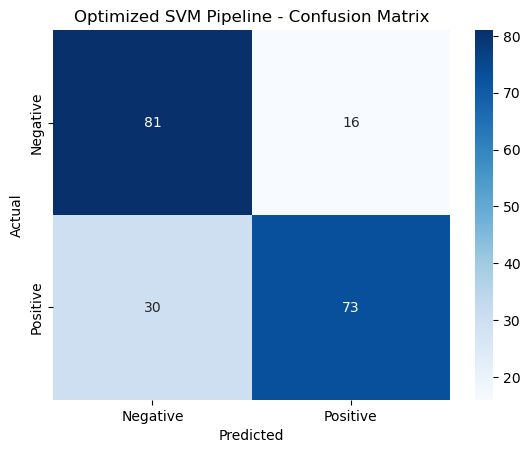

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_pipeline)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Optimized SVM Pipeline - Confusion Matrix")
plt.show()


In [ ]:
import pickle
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

# Load or create TF-IDF vectorizer
tfidf_path = tfidf_load_path
try:
    with open(tfidf_path, "rb") as f:
        tfidf_vect = pickle.load(f)
    print("Loaded existing TF-IDF vectorizer.")
except FileNotFoundError:
    tfidf_vect = TfidfVectorizer(stop_words='english', max_features=5000, smooth_idf=False)
    print("No saved TF-IDF vectorizer found. Creating a new one.")
    with open(tfidf_path, "wb") as f:
        pickle.dump(tfidf_vect, f)
    print("TF-IDF vectorizer saved successfully!")

# Transform text data
x_train_tfidf = tfidf_vect.fit_transform(x_train)
x_test_tfidf = tfidf_vect.transform(x_test)

# Initialize and train Naive Bayes model
naiveBayes_model = MultinomialNB()
naiveBayes_model.fit(x_train_tfidf, y_train)

# Predict on test data
y_pred_nb = naiveBayes_model.predict(x_test_tfidf)

# Evaluate performance
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"\n🔹 Naive Bayes Model Accuracy: {accuracy_nb:.4%}")

# Print classification report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred_nb, target_names=["Negative", "Positive"]))

# Save the trained Naive Bayes model
nb_model_path = naive_bayes_load_path
with open(nb_model_path, "wb") as f:
    pickle.dump(naiveBayes_model, f)
print("\nNaive Bayes model saved successfully!")


No saved TF-IDF vectorizer found. Creating a new one.


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\heman\\OneDrive\\Desktop\\SENTIMENTAL_ANALYSIS\\BACKEND\\Sentimental_Analysis_Loads\\Sentimental_Analysis_tfidf.pkl'

In [ ]:
# y_pred3 = model3.predict(x_test_vect)
# y_pred3
y_pred3 = naiveBayes_model.predict(x_test_tfidf)
y_pred3


array([0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 1], dtype=int64)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Predict using the Naïve Bayes model
y_pred_nb = naiveBayes_model.predict(x_test_tfidf)

# Calculate accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"\n🔹 Naïve Bayes Model Accuracy: {accuracy_nb:.4%}")

# Print detailed classification report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred_nb, target_names=["Negative", "Positive"]))



🔹 Naïve Bayes Model Accuracy: 77.5000%

🔹 Classification Report:

              precision    recall  f1-score   support

    Negative       0.79      0.73      0.76        97
    Positive       0.76      0.82      0.79       103

    accuracy                           0.78       200
   macro avg       0.78      0.77      0.77       200
weighted avg       0.78      0.78      0.77       200



In [ ]:
misclassified_nb = x_test[y_test != y_pred_nb]
print("\n🔍 Misclassified Reviews (First 5):\n", misclassified_nb[:5])



🔍 Misclassified Reviews (First 5):
 ['never again will i be dining at this place'
 'the ambiance isnt much better'
 'the chains which im no fan of beat this place easily'
 'perhaps i caught them on an off night judging by the other reviews but im not inspired to go back'
 'the only thing i did like was the prime rib and dessert section']


In [ ]:

t = tfidf_vect.transform([df['Review'][993]])  # Convert review into TF-IDF features
prediction = naiveBayes_model.predict(t)
print(f"Predicted Sentiment: {prediction[0]}")
print(df['Review'][993])  # Print the actual review text
print(df['Liked'][993]) 

Predicted Sentiment: 0
the presentation of the food was awful.
0


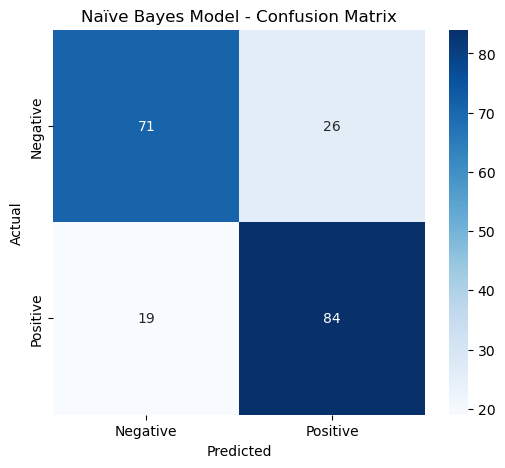

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_nb)

# Plot using Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])

# Labels and title
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naïve Bayes Model - Confusion Matrix")
plt.show()


In [ ]:
import pickle
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# ✅ Use CountVectorizer inside the pipeline
MultinomialNB_model = make_pipeline(CountVectorizer(), MultinomialNB())

# Train the pipeline on raw text data
MultinomialNB_model.fit(x_train, y_train)

# ✅ Predict using raw text (pipeline applies CountVectorizer automatically)
y_pred_nb_cv = MultinomialNB_model.predict(x_test)

# Evaluate the model
accuracy_nb_cv = accuracy_score(y_test, y_pred_nb_cv)
print(f"\n🔹 Multinomial Naïve Bayes (CountVectorizer) Accuracy: {accuracy_nb_cv:.4%}")

# Print classification report
print("\n🔹 Classification Report:\n", classification_report(y_test, y_pred_nb_cv))

# ✅ Save the trained pipeline
nb_pipeline_path = multinomial_nb_pipeline_load_path
with open(nb_pipeline_path, "wb") as f:
    pickle.dump(MultinomialNB_model, f)

print("\n✅ Naïve Bayes pipeline model saved successfully!")



🔹 Multinomial Naïve Bayes (CountVectorizer) Accuracy: 81.0000%

🔹 Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.84      0.81        97
           1       0.84      0.79      0.81       103

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.81      0.81      0.81       200


✅ Naïve Bayes pipeline model saved successfully!


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# ✅ Predict using raw text (pipeline applies CountVectorizer automatically)
y_pred_nb_cv = MultinomialNB_model.predict(x_test)

# Calculate accuracy
accuracy_nb_cv = accuracy_score(y_test, y_pred_nb_cv)
print(f"\n🔹 Multinomial Naïve Bayes (CountVectorizer) Accuracy: {accuracy_nb_cv:.4%}")

# Print detailed classification report
print("\n🔹 Classification Report:\n", classification_report(y_test, y_pred_nb_cv))



🔹 Multinomial Naïve Bayes (CountVectorizer) Accuracy: 81.0000%

🔹 Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.84      0.81        97
           1       0.84      0.79      0.81       103

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.81      0.81      0.81       200



In [ ]:
#predicting output
MultinomialNB_model.predict([df['Review'][993]])

array([0], dtype=int64)

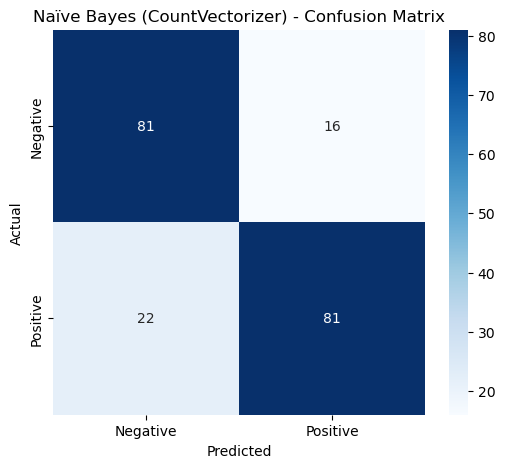

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm_nb_cv = confusion_matrix(y_test, y_pred_nb_cv)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb_cv, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naïve Bayes (CountVectorizer) - Confusion Matrix")
plt.show()


In [ ]:
# Predict using Standard SVM
y_pred1 = svm_model.predict(x_test_tfidf)  # ✅ SVM model expects TF-IDF transformed data

# Predict using Optimized SVM Pipeline
y_pred_svm_pipeline = optimized_pipeline.predict(x_test)  # ✅ Pipeline expects raw text

# Predict using Naïve Bayes (TF-IDF)
y_pred_nb = naiveBayes_model.predict(x_test_tfidf)  # ✅ Naïve Bayes with TF-IDF

# Predict using Naïve Bayes (CountVectorizer)
y_pred_nb_cv = MultinomialNB_model.predict(x_test)  # ✅ Naïve Bayes with CountVectorizer

# Print all accuracies
print('🔹 Accuracy for Standard SVM:', accuracy_score(y_test, y_pred1))  
print('🔹 Accuracy for Optimized SVM Pipeline:', accuracy_score(y_test, y_pred_svm_pipeline))  
print('🔹 Accuracy for Naïve Bayes (TF-IDF):', accuracy_score(y_test, y_pred_nb))  
print('🔹 Accuracy for Naïve Bayes (CountVectorizer):', accuracy_score(y_test, y_pred_nb_cv))  


🔹 Accuracy for Standard SVM: 0.755
🔹 Accuracy for Optimized SVM Pipeline: 0.77
🔹 Accuracy for Naïve Bayes (TF-IDF): 0.775
🔹 Accuracy for Naïve Bayes (CountVectorizer): 0.81


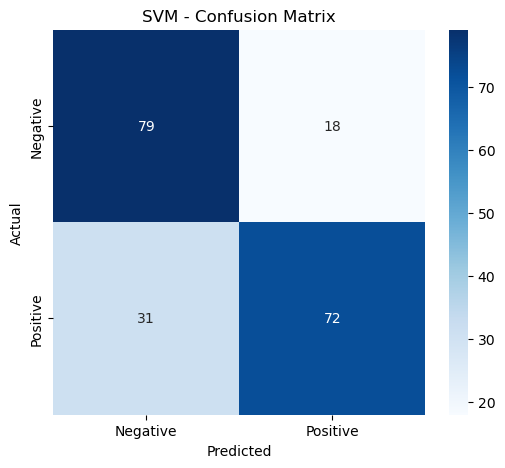

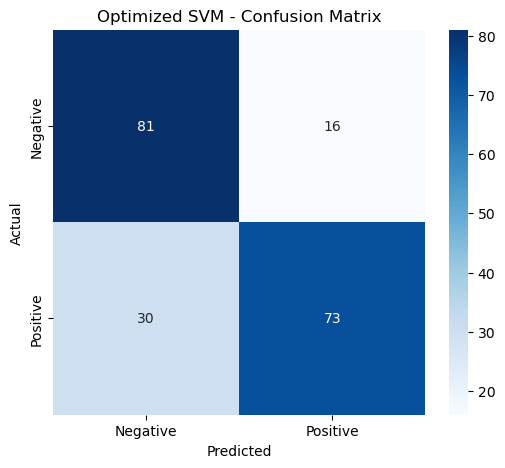

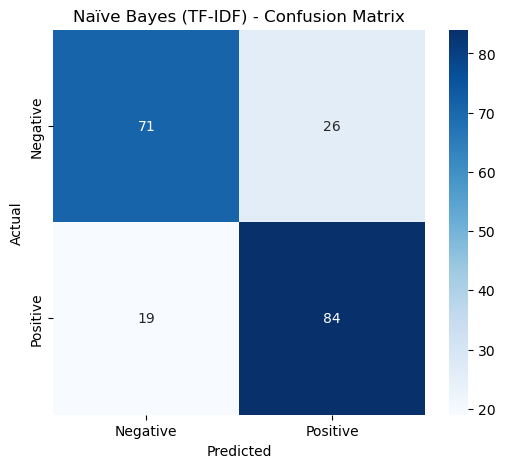

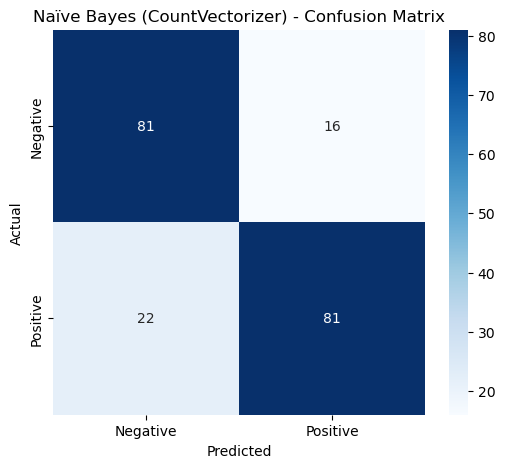

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Store models and predictions
models = {
    "SVM": y_pred1,
    "Optimized SVM": y_pred_svm_pipeline,
    "Naïve Bayes (TF-IDF)": y_pred_nb,
    "Multinomial NB ()": y_pred_nb_cv
}

# Plot confusion matrix for each model
for model_name, y_pred in models.items():
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()


In [ ]:
import joblib

# Load the saved models
svm_model = joblib.load(r"C:\Users\heman\OneDrive\Desktop\SENTIMENTAL_ANALYSIS\BACKEND\Sentimental_Analysis_Loads\Sentimental_Analysis_svm_model.pkl")

svc_pipeline_model = joblib.load(r"C:\Users\heman\OneDrive\Desktop\SENTIMENTAL_ANALYSIS\BACKEND\Sentimental_Analysis_Loads\Sentimental_Analysis_SVM_pipeline.pkl")  # Fixed filename

naivebayes_model = joblib.load(r"C:\Users\heman\OneDrive\Desktop\SENTIMENTAL_ANALYSIS\BACKEND\Sentimental_Analysis_Loads\Sentimental_Analysis_naive_bayes.pkl")

multinomialnb_model = joblib.load(r"C:\Users\heman\OneDrive\Desktop\SENTIMENTAL_ANALYSIS\BACKEND\Sentimental_Analysis_Loads\Sentimental_Analysis_MultinomialNB_model.pkl")

print("✅ Models loaded successfully!")


✅ Models loaded successfully!


In [ ]:

sample_review = ["The food was amazing and the service was excellent!"]

predicted_sentiment = multinomialnb_model.predict(sample_review)

print("Predicted Sentiment:", "Positive" if predicted_sentiment[0] == 1 else "Negative")


Predicted Sentiment: Positive


In [ ]:
test_reviews = [
    "The food was cold and terrible.",
    "Absolutely loved the ambiance and the food was delicious!",
    "Worst experience ever! The staff was rude.",
    "Had a great time. The service was fast and friendly."
]

predicted_sentiments = multinomialnb_model.predict(test_reviews)

for review, sentiment in zip(test_reviews, predicted_sentiments):
    print(f"Review: {review} -> Predicted Sentiment: {'Positive' if sentiment == 1 else 'Negative'}")


Review: The food was cold and terrible. -> Predicted Sentiment: Negative
Review: Absolutely loved the ambiance and the food was delicious! -> Predicted Sentiment: Positive
Review: Worst experience ever! The staff was rude. -> Predicted Sentiment: Negative
Review: Had a great time. The service was fast and friendly. -> Predicted Sentiment: Positive
